# EJERCICIO : COMPARAR MODELOS DE REGRESION PARA ESTE DATASET USED CARS
## DATASET https://www.kaggle.com/datasets/alemazz11/cars-europe

# PASO 1 - INSTALAMOS E IMPORTAMOS LIBRERIAS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.set(style='whitegrid',context='notebook')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alemazz11/cars-europe")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars-europe' dataset.
Path to dataset files: /kaggle/input/cars-europe


In [3]:
!ls /kaggle/input/cars-europe

fullGas.csv


In [4]:
PATH_CSV = path + '/fullGas.csv'

In [6]:
%run '/content/pandas_missing_extension.ipynb'

In [7]:
df = pd.read_csv(PATH_CSV)
df

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,Volvo,V60 Cross Country,Station wagon,73627,32990,2023.0,DE,Used,Diesel,NaN,...,NaN,5.0,5.0,Grey,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40490,Volvo,XC60,Off-Road/Pick-up,93671,26990,2020.0,IT,Used,Electric/Diesel,NaN,...,4.0,5.0,5.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
40491,Volvo,V90,Station wagon,60200,32490,2020.0,DE,Used,Gasoline,NaN,...,4.0,5.0,5.0,Black,Full leather,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
40492,Volvo,XC40,Off-Road/Pick-up,49088,29450,2022.0,NL,Used,Electric/Gasoline,NaN,...,3.0,5.0,5.0,Black,Cloth,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [8]:
df.missing.number_missing()

np.int64(103838)

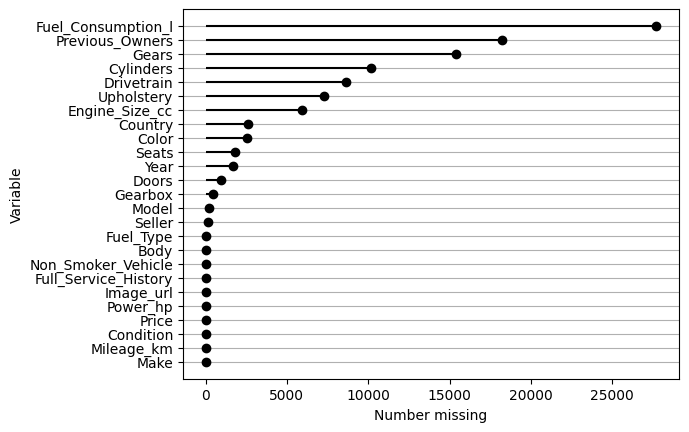

In [9]:
df.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES NÚMERICAS

In [10]:
numerics_nan = ['Fuel_Consumption_l','Previous_Owners','Gears','Cylinders','Engine_Size_cc','Seats','Year','Doors']

In [11]:
df_cleaned = df.copy()

In [12]:
for variable in numerics_nan:
  df_cleaned[variable] = df_cleaned[variable].fillna(float(round(df_cleaned[variable].mean())))

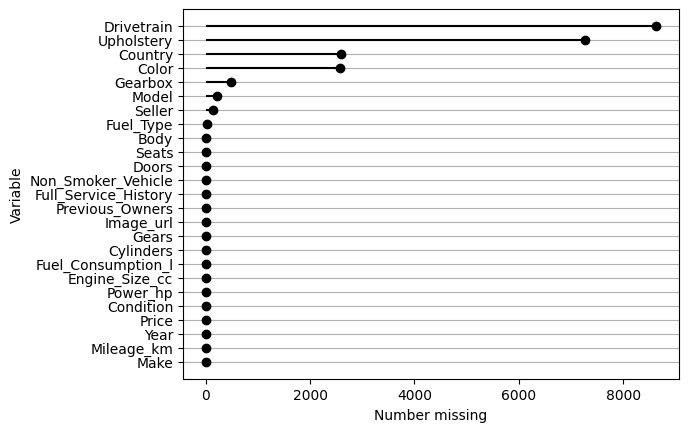

In [13]:
df_cleaned.missing.missing_variable_plot()

# IMPUTACIÓN DE VARIABLES CATEGORICAS

In [14]:
objects_nan = ['Fuel_Type','Body','Drivetrain','Upholstery','Country','Color','Gearbox','Model','Seller']

In [15]:
for variable in objects_nan:
  df_cleaned[variable] = df_cleaned[variable].ffill()
  df_cleaned[variable] = df_cleaned[variable].bfill()

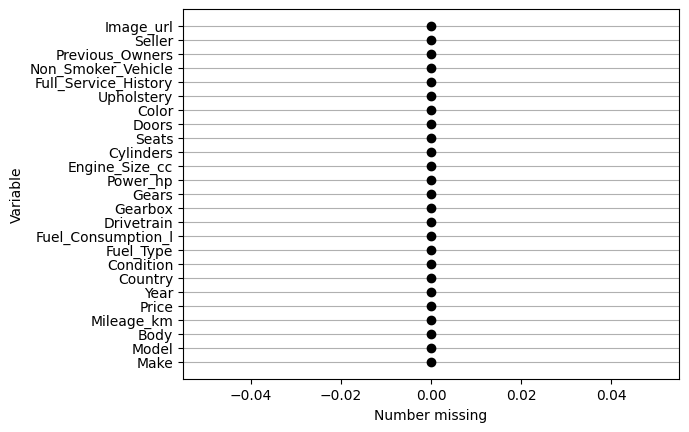

In [16]:
df_cleaned.missing.missing_variable_plot()

In [17]:
df_cleaned.missing.number_missing()

np.int64(0)

In [20]:
df_cleaned.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller', 'Image_url'],
      dtype='object')

In [24]:
df_encoded = df_cleaned[['Mileage_km', 'Price', 'Year',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors', 'Full_Service_History', 'Non_Smoker_Vehicle']].copy()

# CODIFICACIÓN DE VARIABLES CATEGORICAS CON SKLEARN

In [29]:
categorical_columns = df_encoded.select_dtypes(object).columns
categorical_columns

Index(['Condition', 'Fuel_Type', 'Gearbox'], dtype='object')

In [30]:
['Fuel_Type'] = df_encoded['Fuel_Type'].apply(lambda x: x if x == 'Gasoline' else 'Others')

In [32]:
for cc in categorical_columns:
  print("*"*50)
  print(df_encoded[cc].value_counts())

**************************************************
Condition
Used    38701
New      1793
Name: count, dtype: int64
**************************************************
Fuel_Type
Gasoline    22436
Others      18058
Name: count, dtype: int64
**************************************************
Gearbox
Automatic         25676
Manual            14067
Semi-automatic      751
Name: count, dtype: int64


In [33]:
ordinal_cols = ['Condition','Fuel_Type']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
print(ordinal_cols,onehot_cols)

['Condition', 'Fuel_Type'] ['Gearbox']


In [34]:
import sklearn.compose
import sklearn.preprocessing

In [35]:
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['Condition', 'Fuel_Type']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['Gearbox'])])

In [38]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_encoded),
        columns = transformer.get_feature_names_out(),
        index=df_encoded.index
    )
)
data_transformed_df

,ordinalencoder__Condition,ordinalencoder__Fuel_Type,onehotencoder__Gearbox_Automatic,onehotencoder__Gearbox_Manual,onehotencoder__Gearbox_Semi-automatic,remainder__Mileage_km,remainder__Price,remainder__Year,remainder__Fuel_Consumption_l,remainder__Gears,remainder__Power_hp,remainder__Engine_Size_cc,remainder__Cylinders,remainder__Seats,remainder__Doors,remainder__Full_Service_History,remainder__Non_Smoker_Vehicle
0,1.0,0.0,1.0,0.0,0.0,98000,16900,2020.0,6.7,6.0,179,1368.0,4.0,4.0,3.0,False,False
1,1.0,0.0,0.0,1.0,0.0,91500,12500,2017.0,6.0,5.0,165,1368.0,4.0,4.0,3.0,False,True
2,1.0,0.0,0.0,1.0,0.0,40000,17990,2015.0,6.5,5.0,300,1368.0,4.0,4.0,3.0,True,True
3,1.0,0.0,0.0,1.0,0.0,133000,9300,2008.0,6.5,5.0,160,1368.0,4.0,4.0,3.0,True,True
4,1.0,0.0,0.0,1.0,0.0,61019,14990,2021.0,7.0,6.0,145,1368.0,4.0,4.0,3.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,1.0,1.0,0.0,0.0,73627,32990,2023.0,7.0,6.0,197,1969.0,5.0,5.0,5.0,True,True
40490,1.0,1.0,1.0,0.0,0.0,93671,26990,2020.0,7.0,8.0,197,1969.0,4.0,5.0,5.0,False,False
40491,1.0,0.0,1.0,0.0,0.0,60200,32490,2020.0,7.0,8.0,190,1969.0,4.0,5.0,5.0,True,True
40492,1.0,1.0,1.0,0.0,0.0,49088,29450,2022.0,7.0,7.0,211,1477.0,3.0,5.0,5.0,True,False


In [39]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,Condition,Fuel_Type,Gearbox_Automatic,Gearbox_Manual,Gearbox_Semi-automatic,Mileage_km,Price,Year,Fuel_Consumption_l,Gears,Power_hp,Engine_Size_cc,Cylinders,Seats,Doors,Full_Service_History,Non_Smoker_Vehicle
0,1.0,0.0,1.0,0.0,0.0,98000,16900,2020.0,6.7,6.0,179,1368.0,4.0,4.0,3.0,False,False
1,1.0,0.0,0.0,1.0,0.0,91500,12500,2017.0,6.0,5.0,165,1368.0,4.0,4.0,3.0,False,True
2,1.0,0.0,0.0,1.0,0.0,40000,17990,2015.0,6.5,5.0,300,1368.0,4.0,4.0,3.0,True,True
3,1.0,0.0,0.0,1.0,0.0,133000,9300,2008.0,6.5,5.0,160,1368.0,4.0,4.0,3.0,True,True
4,1.0,0.0,0.0,1.0,0.0,61019,14990,2021.0,7.0,6.0,145,1368.0,4.0,4.0,3.0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40489,1.0,1.0,1.0,0.0,0.0,73627,32990,2023.0,7.0,6.0,197,1969.0,5.0,5.0,5.0,True,True
40490,1.0,1.0,1.0,0.0,0.0,93671,26990,2020.0,7.0,8.0,197,1969.0,4.0,5.0,5.0,False,False
40491,1.0,0.0,1.0,0.0,0.0,60200,32490,2020.0,7.0,8.0,190,1969.0,4.0,5.0,5.0,True,True
40492,1.0,1.0,1.0,0.0,0.0,49088,29450,2022.0,7.0,7.0,211,1477.0,3.0,5.0,5.0,True,False


In [41]:
corr_matrix = data_transformed_df.corr()
corr_charges = corr_matrix['Price']
corr_charges.sort_values(ascending=False)

,Price
Price,1.000000
Power_hp,0.468264
Cylinders,0.337319
Engine_Size_cc,0.326771
Fuel_Consumption_l,0.130321
Gearbox_Automatic,0.128364
Gears,0.090620
Gearbox_Semi-automatic,0.022485
Year,0.013881
Full_Service_History,0.012564


In [42]:
cols = corr_charges.index.tolist()
cols.remove('Price')
cols

['Condition',
 'Fuel_Type',
 'Gearbox_Automatic',
 'Gearbox_Manual',
 'Gearbox_Semi-automatic',
 'Mileage_km',
 'Year',
 'Fuel_Consumption_l',
 'Gears',
 'Power_hp',
 'Engine_Size_cc',
 'Cylinders',
 'Seats',
 'Doors',
 'Full_Service_History',
 'Non_Smoker_Vehicle']

In [43]:
X = data_transformed_df[cols].values
y = data_transformed_df['Price'].values.reshape(-1,1)